# Predict Energy Behavior of Prosumers
## Kaggle Competition | End-to-End ML Pipeline

**Author:** David Tam | MSc Physics, SFU | [GitHub](https://github.com/David-Tam)

---

### Project Summary
This notebook builds a complete machine learning pipeline to forecast the **energy imbalance** 
of prosumers (households and businesses that both consume and produce energy) in Estonia.

The target variable is the difference between actual and scheduled energy production/consumption.
Accurate forecasting reduces grid instability and operational costs for energy providers.

### Pipeline Overview
| Phase | Description |
|---|---|
| 1 — Data Loading | Load and inspect 6 raw data sources |
| 2 — EDA | Understand target distribution, seasonality, and missingness |
| 3 — Merging | Join all sources into a unified feature table |
| 4 — Feature Engineering | Datetime features, lag features (no-lookahead design) |
| 5 — Baseline | 48-hour persistence baseline MAE |
| 6 — Modelling | XGBoost and LightGBM with early stopping |
| 7 — Optuna Tuning | Bayesian hyperparameter optimisation with TimeSeriesSplit CV |
| 8 — SHAP Analysis | Global and local model explainability |

### Key Results
| Model | Validation MAE |
|---|---|
| Persistence Baseline (48h lag) | 99.04 |
| XGBoost (default) | 60.29 |
| LightGBM (default) | 66.07 |
| XGBoost (Optuna tuned) | **58.06** |

> Tuned XGBoost achieves a **41.4% reduction in MAE** over the persistence baseline.

# Phase 1 — Data Loading

The competition provides 6 raw data sources. Before loading, we inspect file sizes to 
understand memory requirements, then load each file and examine its shape and schema.

| File | Description | Join Key |
|---|---|---|
| `train.csv` | Target variable (energy imbalance) per prosumer per hour | `county`, `is_business`, `product_type`, `datetime` |
| `client.csv` | Prosumer metadata — installed capacity, contract type | `county`, `is_business`, `product_type`, `date` |
| `historical_weather.csv` | Actual observed weather per station per hour | `latitude`, `longitude`, `datetime` |
| `forecast_weather.csv` | Predicted weather per station per forecast hour | `latitude`, `longitude`, `forecast_datetime` |
| `electricity_prices.csv` | Hourly electricity spot price (EUR/MWh) | `forecast_date` |
| `gas_prices.csv` | Daily gas price range (EUR/MWh) | `forecast_date` |
| `weather_station_to_county_mapping.csv` | Maps lat/lon coordinates to Estonian county codes | `latitude`, `longitude` |

`train.csv` is the **base table** — all other files will be merged onto it.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Kaggle competition data path — run on Kaggle to reproduce
DATA_DIR = '/kaggle/input/competitions/predict-energy-behavior-of-prosumers/'

for f in os.listdir(DATA_DIR):
    size_mb = os.path.getsize(DATA_DIR + f) / 1e6
    print(f'{f:50s} {size_mb:.1f} MB')


df_train = pd.read_csv(DATA_DIR + 'train.csv')
df_client = pd.read_csv(DATA_DIR + 'client.csv')
df_electricity_prices = pd.read_csv(DATA_DIR + 'electricity_prices.csv')
df_forecast_weather = pd.read_csv(DATA_DIR + 'forecast_weather.csv')
df_gas_prices = pd.read_csv(DATA_DIR + 'gas_prices.csv')
df_historical_weather = pd.read_csv(DATA_DIR + 'historical_weather.csv')
df_weather_station_to_county_mapping = pd.read_csv(DATA_DIR + 'weather_station_to_county_mapping.csv')

print('---------------------------------------------------------------------------')

print('=== Train Info ===')
print(f'train shape:                          {df_train.shape}')
print(f'train:\n                              {df_train.head(2)}\n')

print('=== Client Info ===')
print(f'client shape:                         {df_client.shape}')
print(f'client:\n                             {df_client.head(2)}\n')

print('=== Electricity_Prices Info ===')
print(f'electricity_prices shape:               {df_electricity_prices.shape}')
print(f'electricity_prices:\n                   {df_electricity_prices.head(2)}\n')

print('=== Forecast_Weather Info ===')
print(f'forecast_weather shape:                     {df_forecast_weather.shape}')
print(f'forecast_weather:\n                     {df_forecast_weather.head(2)}\n')

print('=== Gas_Prices Info ===')
print(f'gas_prices shape:                           {df_gas_prices.shape}')
print(f'gas_prices:\n                           {df_gas_prices.head(2)}\n')

print('=== Historical_Weather Info ===')
print(f'historical_weather shape:                   {df_historical_weather.shape}')
print(f'historical_weather:\n                   {df_historical_weather.head(2)}\n')

print('=== Weather_Station_to_County_Mapping Info ===')
print(f'weather_station_to_county_mapping shape:    {df_weather_station_to_county_mapping.shape}')
print(f'weather_station_to_county_mapping:\n    {df_weather_station_to_county_mapping.head(2)}\n')

client.csv                                         1.4 MB
gas_prices.csv                                     0.0 MB
electricity_prices.csv                             0.8 MB
weather_station_to_county_mapping.csv              0.0 MB
example_test_files                                 0.0 MB
enefit                                             0.0 MB
public_timeseries_testing_util.py                  0.0 MB
historical_weather.csv                             180.5 MB
county_id_to_name_map.json                         0.0 MB
train.csv                                          99.0 MB
forecast_weather.csv                               781.1 MB
---------------------------------------------------------------------------
=== Train Info ===
train shape:                          (2018352, 9)
train:
                                 county  is_business  product_type  target  is_consumption  \
0       0            0             1   0.713               0   
1       0            0             1  96.590  

# Phase 2 — Exploratory Data Analysis

Before any feature engineering, we inspect the data to understand:
- **Missingness** — which columns have nulls and how many
- **Target distribution** — skewness and outlier presence inform loss function choice
- **Target over time** — reveals seasonality, trends, and data gaps
- **Prosumer breakdown** — how energy imbalance differs across business type and product type

## Key Design Decision: Loss Function
The target is right-skewed with large outliers. We use **MAE (Mean Absolute Error)** rather 
than RMSE because:
- MAE is linear — outliers are penalised proportionally, not exponentially
- Extreme energy events (heatwaves, grid failures) are real events the model should learn from, not noise to suppress
- Removing outliers would cause the model to fail precisely when accurate prediction matters most

=== Train-Missing Values (Percentage) ===
        null_count  null_pct
target         528   0.02616

=== Client-Missing Values (Percentage) ===
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

=== Electricity Prices-Missing Values (Percentage) ===
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

=== Forecast Weather-Missing Values (Percentage) ===
                                   null_count  null_pct
surface_solar_radiation_downwards           2  0.000058

=== Gas Prices-Missing Values (Percentage) ===
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

=== Historical Weather-Missing Values (Percentage) ===
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

=== Weather Station to County Mapping-Missing Values (Percentage) ===
             null_count  null_pct
county_name          63     56.25
county               63     56.25

=== Target Distribution ===


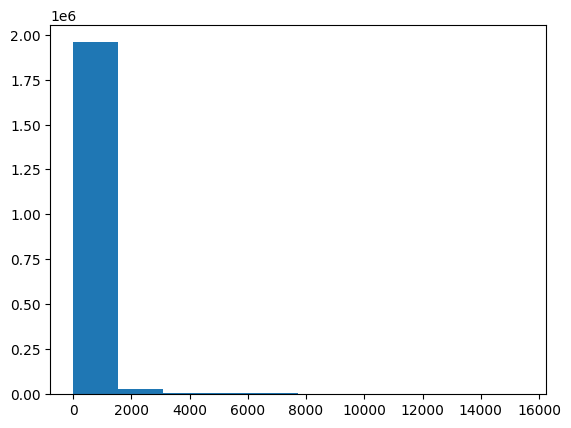

Value_counts: target
0.000      351496
0.001       10733
0.003        6619
0.002        5365
0.004        4593
            ...  
890.132         1
581.055         1
273.470         1
83.630          1
179.893         1
Name: count, Length: 565566, dtype: int64
Skewness: 7.6760620718062675

=== Outlier Detection ===
Outlier count: 274,217
Outlier pct:   13.59%

=== Target Over Time ===


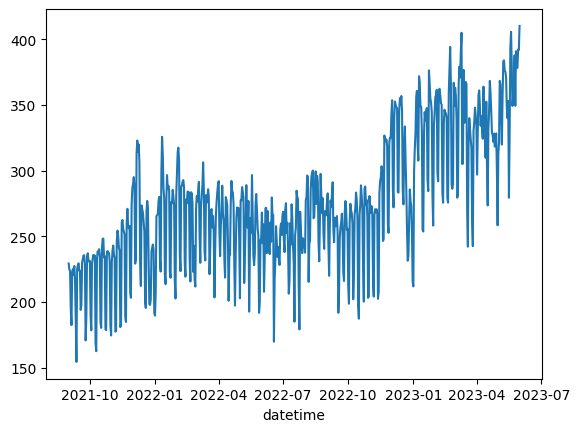


=== Prosumer breakdown ===


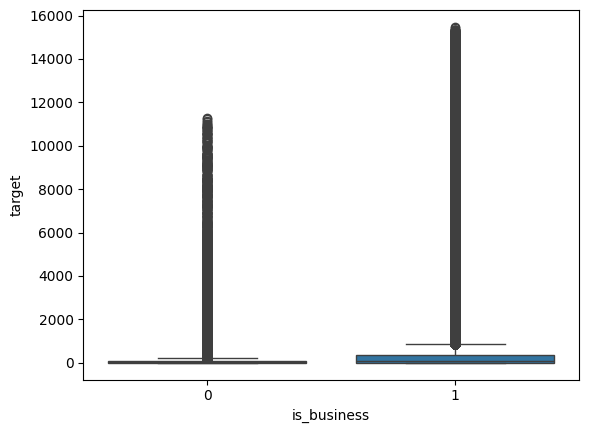

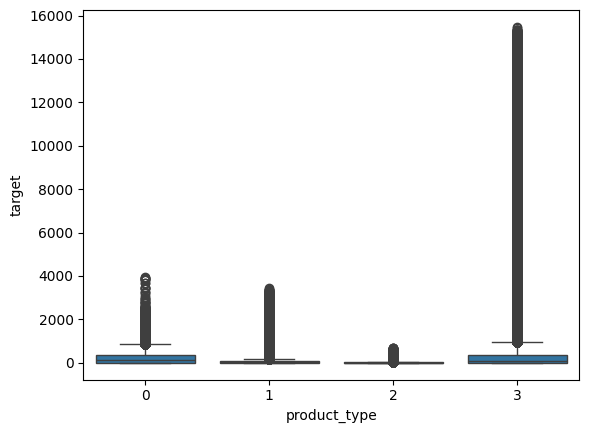

In [4]:
print('=== Train-Missing Values (Percentage) ===')
n_train = pd.DataFrame({
    'null_count': df_train.isnull().sum(),
    'null_pct':   df_train.isnull().mean() * 100
})
print(n_train[n_train.null_count > 0])

print(f'\n=== Client-Missing Values (Percentage) ===')
n_client = pd.DataFrame({
    'null_count': df_client.isnull().sum(),
    'null_pct':   df_client.isnull().mean() * 100
})
print(n_client[n_client.null_count > 0])

print(f'\n=== Electricity Prices-Missing Values (Percentage) ===')
n_electricity_prices = pd.DataFrame({
    'null_count': df_electricity_prices.isnull().sum(),
    'null_pct':   df_electricity_prices.isnull().mean() * 100
})
print(n_electricity_prices[n_electricity_prices.null_count > 0])

print(f'\n=== Forecast Weather-Missing Values (Percentage) ===')
n_forecast_weather = pd.DataFrame({
    'null_count': df_forecast_weather.isnull().sum(),
    'null_pct':   df_forecast_weather.isnull().mean() * 100
})
print(n_forecast_weather[n_forecast_weather.null_count > 0])

print(f'\n=== Gas Prices-Missing Values (Percentage) ===')
n_gas_prices = pd.DataFrame({
    'null_count': df_gas_prices.isnull().sum(),
    'null_pct':   df_gas_prices.isnull().mean() * 100
})
print(n_gas_prices[n_gas_prices.null_count > 0])

print(f'\n=== Historical Weather-Missing Values (Percentage) ===')
n_historical_weather = pd.DataFrame({
    'null_count': df_historical_weather.isnull().sum(),
    'null_pct':   df_historical_weather.isnull().mean() * 100
})
print(n_historical_weather[n_historical_weather.null_count > 0])

print(f'\n=== Weather Station to County Mapping-Missing Values (Percentage) ===')
n_weather_station_to_county_mapping = pd.DataFrame({
    'null_count': df_weather_station_to_county_mapping.isnull().sum(),
    'null_pct':   df_weather_station_to_county_mapping.isnull().mean() * 100
})
print(n_weather_station_to_county_mapping[n_weather_station_to_county_mapping.null_count > 0])

print(f'\n=== Target Distribution ===')
plt.hist(df_train['target'])
plt.show()
print(f"Value_counts: {df_train['target'].value_counts()}")
print(f"Skewness: {df_train['target'].skew()}")

print(f'\n=== Outlier Detection ===')
Q1 = df_train['target'].quantile(0.25)
Q3 = df_train['target'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
higher = Q3 + 1.5*IQR
outliers = df_train[(df_train['target']<lower)|(df_train['target']>higher)]
print(f"Outlier count: {len(outliers):,}")
print(f"Outlier pct:   {len(outliers)/len(df_train)*100:.2f}%")

print(f'\n=== Target Over Time ===')
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
date_info = df_train.groupby(df_train['datetime'].dt.date)['target'].mean()
date_info.plot()
plt.show()

print(f'\n=== Prosumer breakdown ===')
#probrea = df_train['target'].groupby(df_train['is_business']).sum()
sns.boxplot(data=df_train, x='is_business', y='target')
plt.show()
#probrea2 = df_train['target'].groupby(df_train['product_type']).sum()
sns.boxplot(data=df_train, x='product_type', y='target')
plt.show()

# Phase 3 — Data Merging

We merge all 6 sources onto the base train table using left joins to preserve all training rows.

## Key Design Decisions

**Join granularity matching:** Before each merge, both sides must share the same grain on join keys.
- `client.csv` is daily → join on `date` (not `datetime`)
- `gas_prices.csv` is daily → join on `date`
- `electricity_prices.csv` is hourly → join on `datetime`
- Weather is per-station → aggregate to county level first, then join on `county + datetime`

**Weather station mapping:** Weather data is indexed by lat/lon coordinates, not by county.
We map stations to counties using the coordinate mapping file, then average weather readings 
across all stations within each county before joining. 63 of 112 weather stations fall outside 
Estonian county boundaries and are dropped.

**Historical vs Forecast weather:** Both are retained as separate features:
- `hist_*` columns: what the weather *actually was* (ground truth)
- `fcst_*` columns: what the weather was *predicted to be* (what prosumers reacted to)

The gap between forecast and actual is itself an informative signal.

### Final merged shape: (2,018,352 rows × 37 columns)
Row count is preserved throughout all 6 merges — no many-to-many joins occurred.

In [5]:
print('=== Train and Client ===')
print(f'Train_original_shape:  {df_train.shape}')
print(f'Client_original_shape: {df_client.shape}')
df_train['date'] = df_train['datetime'].dt.date
df_tc = pd.merge(df_train, df_client, 
                 left_on = ['county', 'is_business', 'product_type', 'date'], 
                 right_on = ['county', 'is_business', 'product_type', 'date'], 
                 how='left'
                )

print(f'\n=== Train and Electricity Prices ===')
print(f'Train_original_shape:  {df_tc.shape}')
print(f'Electricity_Prices_original_shape:  {df_electricity_prices.shape}')
df_electricity_prices['datetime']=pd.to_datetime(df_electricity_prices['forecast_date'])
df_tce = pd.merge(df_tc, df_electricity_prices[['datetime', 'euros_per_mwh']],
                 on = ['datetime'], 
                 how = 'left')

print(f'\n=== Train and Gas Prices ===')
print(f'Train_original_shape:  {df_tce.shape}')
print(f'Gas_Prices_original_shape:  {df_gas_prices.shape}')
df_gas_prices['date']=pd.to_datetime(df_gas_prices['forecast_date']).dt.date
df_tceg = pd.merge(df_tce, df_gas_prices[['date', 'lowest_price_per_mwh','highest_price_per_mwh']],
                   on = ['date'], 
                   how = 'left')

print(f"Shape before: {df_tce.shape}")
print(f"Shape after:  {df_tceg.shape}")
print(f"Gas price nulls: {df_tceg['lowest_price_per_mwh'].isnull().sum()}")

print('---------------------------------------------------------------------------')

print(f'\n=== Train and Historical Weather ===')
print(f'Train_original_shape:  {df_tceg.shape}')
print(f'Historical_Weather_original_shape:  {df_historical_weather.shape}')
print(f'Weather_Station_to_County_Mapping_original_shape:  {df_weather_station_to_county_mapping.shape}')

df_historical_weather['coord_key'] = (
    df_historical_weather['latitude'].round(1).astype(str) + '_' + 
    df_historical_weather['longitude'].round(1).astype(str)
)

df_weather_station_to_county_mapping['coord_key'] = (
    df_weather_station_to_county_mapping['latitude'].round(1).astype(str) + '_' + 
    df_weather_station_to_county_mapping['longitude'].round(1).astype(str)
)

df_historical_weather_c = pd.merge(df_historical_weather, 
                                   df_weather_station_to_county_mapping[['coord_key','county']],
                                   on = ['coord_key'],
                                   how = 'left'    
)

df_historical_weather_c = df_historical_weather_c.dropna(subset=['county'])

print(f"Shape before (df_historical_weather): {df_historical_weather.shape}")
print(f"Shape after (df_historical_weather_c):  {df_historical_weather_c.shape}")
print(f"County nulls df_historical_weather_c: {df_historical_weather_c['county'].isnull().sum()}")

df_historical_weather_c['county'] = df_historical_weather_c['county'].astype(int)

df_historical_weather_agg = (df_historical_weather_c.groupby(['county', 'datetime']).mean(numeric_only=True).reset_index())

print(df_tceg['datetime'].dtype)
print(df_historical_weather_agg['datetime'].dtype)

df_historical_weather_agg['datetime'] = pd.to_datetime(df_historical_weather_agg['datetime'])

print(df_tceg['datetime'].dtype)
print(df_historical_weather_agg['datetime'].dtype)

df_tcegh = pd.merge(df_tceg, df_historical_weather_agg, 
                    on = ['county', 'datetime'],
                    how = 'left'
)

print(f"Shape before (df_tceg): {df_tceg.shape}")
print(f"Shape after (df_tcegh):  {df_tcegh.shape}")

print('---------------------------------------------------------------------------')

print(f'\n=== Train and Forecast Weather ===')
print(f'Train_original_shape:  {df_tcegh.shape}')
print(f'Forecast_Weather_original_shape:  {df_forecast_weather.shape}')
print(f'Weather_Station_to_County_Mapping_original_shape:  {df_weather_station_to_county_mapping.shape}')

df_forecast_weather['coord_key'] = (
    df_forecast_weather['latitude'].round(1).astype(str) + '_' + 
    df_forecast_weather['longitude'].round(1).astype(str)
)

df_forecast_weather_c = pd.merge(df_forecast_weather, 
                                   df_weather_station_to_county_mapping[['coord_key','county']],
                                   on = ['coord_key'],
                                   how = 'left'    
)

df_forecast_weather_c = df_forecast_weather_c.dropna(subset=['county'])

print(f"Shape before (df_forecast_weather): {df_forecast_weather.shape}")
print(f"Shape after (df_forecast_weather_c):  {df_forecast_weather_c.shape}")
print(f"County nulls df_forecast_weather_c: {df_forecast_weather_c['county'].isnull().sum()}")

df_forecast_weather_c['county'] = df_forecast_weather_c['county'].astype(int)

df_forecast_weather_c_agg = (df_forecast_weather_c.groupby(['county', 'forecast_datetime']).mean(numeric_only = True).reset_index())

print(df_tcegh['datetime'].dtype)
print(df_forecast_weather_c_agg['forecast_datetime'].dtype)

df_forecast_weather_c_agg['forecast_datetime'] = pd.to_datetime(df_forecast_weather_c_agg['forecast_datetime'])

df_forecast_weather_c_agg = df_forecast_weather_c_agg.drop(columns = ['data_block_id'])

print(df_tcegh['datetime'].dtype)
print(df_forecast_weather_c_agg['forecast_datetime'].dtype)

df_tceghf = pd.merge(df_tcegh, df_forecast_weather_c_agg, 
                     left_on = ['county', 'datetime'], 
                     right_on = ['county', 'forecast_datetime'], 
                     how = 'left'
)

print(f"Shape before (df_tcegh): {df_tcegh.shape}")
print(f"Shape after (df_tceghf):  {df_tceghf.shape}")

print('---------------------------------------------------------------------------')

print(f'\n=== Drop Useless Columns ===')
print('df_tceghf original shape', df_tceghf.shape)

drop_columns = ['data_block_id_x', 'row_id', 'prediction_unit_id', 'data_block_id_y', 
                'data_block_id', 'latitude_x', 'longitude_x', 'latitude_y', 
                'longitude_y', 'date', 'forecast_datetime', 'hours_ahead']

df_tceghf = df_tceghf.drop(columns = drop_columns)
print('df_tceghf final shape', df_tceghf.shape)

print(f'\n=== Rename ===')

df_merged = df_tceghf.rename(columns = {
    'temperature_x':          'hist_temperature',
    'temperature_y':          'fcst_temperature',
    'dewpoint_x':             'hist_dewpoint',
    'dewpoint_y':             'fcst_dewpoint',
    'snowfall_x':             'hist_snowfall',
    'snowfall_y':             'fcst_snowfall',
    'cloudcover_total_x':     'hist_cloudcover_total',
    'cloudcover_total_y':     'fcst_cloudcover_total',
    'cloudcover_low_x':       'hist_cloudcover_low',
    'cloudcover_low_y':       'fcst_cloudcover_low',
    'cloudcover_mid_x':       'hist_cloudcover_mid',
    'cloudcover_mid_y':       'fcst_cloudcover_mid',
    'cloudcover_high_x':      'hist_cloudcover_high',
    'cloudcover_high_y':      'fcst_cloudcover_high',
    'direct_solar_radiation_x': 'hist_direct_solar_radiation',
    'direct_solar_radiation_y': 'fcst_direct_solar_radiation'
})

print(df_merged.columns.tolist())
print(df_merged.shape)

=== Train and Client ===
Train_original_shape:  (2018352, 9)
Client_original_shape: (41919, 7)

=== Train and Electricity Prices ===
Train_original_shape:  (2018352, 13)
Electricity_Prices_original_shape:  (15286, 4)

=== Train and Gas Prices ===
Train_original_shape:  (2018352, 14)
Gas_Prices_original_shape:  (637, 5)
Shape before: (2018352, 14)
Shape after:  (2018352, 16)
Gas price nulls: 3120
---------------------------------------------------------------------------

=== Train and Historical Weather ===
Train_original_shape:  (2018352, 16)
Historical_Weather_original_shape:  (1710802, 18)
Weather_Station_to_County_Mapping_original_shape:  (112, 4)
Shape before (df_historical_weather): (1710802, 19)
Shape after (df_historical_weather_c):  (748475, 20)
County nulls df_historical_weather_c: 0
datetime64[ns]
object
datetime64[ns]
datetime64[ns]
Shape before (df_tceg): (2018352, 16)
Shape after (df_tcegh):  (2018352, 33)
------------------------------------------------------------------

# Phase 4 — Feature Engineering

## Datetime Features
Energy consumption is highly cyclical. We decompose the timestamp into components the 
model can split on: hour, month, day of week, quarter, day of year, week of year, is_weekend.

## Lag Features — Autoregression with No-Lookahead Design
The most powerful features in energy forecasting are **past values of the target itself**.
This is called autoregression — using past observations to predict future ones.

**Critical constraint:** At prediction time for hour `t`, we only know the target up to 
hour `t-48` (2 days ago) per competition rules. Using any shorter lag would constitute 
**temporal leakage** — the model would see information it cannot have in production.

| Feature | Lookback | Hours shifted |
|---|---|---|
| `lag_2d` | 2 days | 48 |
| `lag_3d` | 3 days | 72 |
| `lag_7d` | 7 days | 168 |
| `lag_14d` | 14 days | 336 |

Lags are computed **within prosumer groups** (`county`, `is_business`, `product_type`, 
`is_consumption`) to prevent cross-prosumer contamination.

## Rolling Features
Rolling statistics over `lag_2d` (not `target`) capture recent trends without leakage:
- `rolling_mean_7d` — smoothed average of recent energy behaviour
- `rolling_std_7d` — volatility of recent energy behaviour

**Total features after engineering: 50**

In [6]:
print('=== Feature_Engineering-Time_features ===')
print(f'df_merged shape before adding time features, {df_merged.shape}')

df_merged['hour'] = df_merged['datetime'].dt.hour
df_merged['month'] = df_merged['datetime'].dt.month
df_merged['day_of_week'] = df_merged['datetime'].dt.dayofweek
df_merged['quarter'] = df_merged['datetime'].dt.quarter
df_merged['day_of_year'] = df_merged['datetime'].dt.dayofyear
df_merged['week_of_year'] = df_merged['datetime'].dt.isocalendar().week.astype(int)

df_merged['is_weekend'] = (df_merged['datetime'].dt.dayofweek >= 5).astype(int)
print(f'df_merged shape after adding time features, {df_merged.shape}\n')
print(df_merged.columns.tolist())

print('---------------------------------------------------------------------------')

print('=== Grouping_Features_For_Time_Shift ===')
print(f'df_merged shape before time shifts, {df_merged.shape}')
#Define the prosumer group keys
group_keys = ['county', 'is_business', 'product_type', 'is_consumption']

#Sort so time is in order within each group
df_merged = df_merged.sort_values(group_keys + ['datetime'])

#Time shift
df_merged['lag_2d'] = df_merged.groupby(group_keys)['target'].shift(48)
df_merged['lag_3d'] = df_merged.groupby(group_keys)['target'].shift(72)
df_merged['lag_7d'] = df_merged.groupby(group_keys)['target'].shift(168)
df_merged['lag_14d'] = df_merged.groupby(group_keys)['target'].shift(336)
print(f'df_merged shape after time shifts, {df_merged.shape}')
print(df_merged.columns.tolist())

print('---------------------------------------------------------------------------')

print('=== Adding_Rolling_Features ===')
print(f'df_merged shape before rolling, {df_merged.shape}')
df_merged['rolling_mean_7d'] = (df_merged
                                .groupby(group_keys)['lag_2d']
                                .transform(lambda x: x.rolling(168, min_periods=1).mean())
                               )
df_merged['rolling_std_7d'] = (df_merged
                                .groupby(group_keys)['lag_2d']
                                .transform(lambda x: x.rolling(168, min_periods=1).std())
                              )

print(df_merged[['datetime', 'target', 'lag_2d', 'lag_7d', 'rolling_mean_7d']].head(20))
print(f"Total features: {df_merged.shape[1]}")

=== Feature_Engineering-Time_features ===
df_merged shape before adding time features, (2018352, 37)
df_merged shape after adding time features, (2018352, 44)

['county', 'is_business', 'product_type', 'target', 'is_consumption', 'datetime', 'eic_count', 'installed_capacity', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'hist_temperature', 'hist_dewpoint', 'rain', 'hist_snowfall', 'surface_pressure', 'hist_cloudcover_total', 'hist_cloudcover_low', 'hist_cloudcover_mid', 'hist_cloudcover_high', 'windspeed_10m', 'winddirection_10m', 'shortwave_radiation', 'hist_direct_solar_radiation', 'diffuse_radiation', 'fcst_temperature', 'fcst_dewpoint', 'fcst_cloudcover_high', 'fcst_cloudcover_low', 'fcst_cloudcover_mid', 'fcst_cloudcover_total', '10_metre_u_wind_component', '10_metre_v_wind_component', 'fcst_direct_solar_radiation', 'surface_solar_radiation_downwards', 'fcst_snowfall', 'total_precipitation', 'hour', 'month', 'day_of_week', 'quarter', 'day_of_year', 'week_of_ye

# Phase 5 — Train/Val Split & Persistence Baseline

## Time-Based Split
We split on calendar date, not randomly. A random split would allow the model to train on 
future data and validate on past data — this is **temporal leakage** and would produce 
optimistic but meaningless validation scores.

| Set | Date range | Rows |
|---|---|---|
| Train | 2021-09-01 → 2022-12-31 | 1,537,584 (~76%) |
| Validation | 2023-01-01 → 2023-05-31 | 480,768 (~24%) |

## Persistence Baseline
The simplest possible forecast: predict that the energy imbalance today equals the imbalance 
from 48 hours ago (`lag_2d`). This is the industry-standard sanity check for time series models.

**Persistence Baseline MAE: 99.04**

Any model that cannot beat 99.04 is not useful. This is our "before" benchmark.

In [7]:
# choose 2023-01-01 as a cutoff date
split_date = '2023-01-01'

df_train_final = df_merged[df_merged['datetime'] < split_date]
df_train_final = df_train_final.dropna(subset = ['target'])
df_val = df_merged[df_merged['datetime'] >= split_date]
df_val = df_val.dropna(subset = ['target'])

features = df_merged.columns.drop(['target', 'datetime']).tolist()

X_train = df_train_final[features]
X_val = df_val[features]

y_train = df_train_final['target']
y_val = df_val['target']

date_train = df_train_final['datetime']
date_val = df_val['datetime']

print(f'df_merged shape', df_merged.shape)
print(f'X_train shape', X_train.shape)
print(f'X_val shape', X_val.shape)
print(f'y_train shape', y_train.shape)
print(f'y_val shape', y_val.shape)

df_merged shape (2018352, 50)
X_train shape (1537188, 48)
X_val shape (480636, 48)
y_train shape (1537188,)
y_val shape (480636,)


## Baseline Model

In [8]:
# Baseline model predict that the target 48 hours ago equals the target now.
# This is the "dumb benchmark" that my models must beat later.

from sklearn.metrics import mean_absolute_error

# lag_2d is already target from 48h ago — that's our persistence prediction
val_with_lags = df_val.dropna(subset = ['target', 'lag_2d'])

persistence_mae = mean_absolute_error(val_with_lags['target'], val_with_lags['lag_2d'])
print(f"Persistence Baseline MAE: {persistence_mae:.4f}")
print(f"Rows evaluated: {len(val_with_lags):,}")

print(f"Target mean:   {df_val['target'].mean():.2f}")
print(f"Target std:    {df_val['target'].std():.2f}")
print(f"Target median: {df_val['target'].median():.2f}")

Persistence Baseline MAE: 99.0384
Rows evaluated: 480,504
Target mean:   336.86
Target std:    1049.18
Target median: 45.39


# Phase 6 — Model Training

We train two gradient boosting models with early stopping on the time-based validation split.

## Configuration
| Setting | Value | Reason |
|---|---|---|
| Objective | `reg:absoluteerror` / `mae` | Consistent with MAE evaluation metric |
| Early stopping | 50 rounds | Stops training when val MAE stagnates |
| n_estimators | 1000–3000 | Upper bound; early stopping finds optimal |
| Learning rate | 0.05 | Conservative — allows fine-grained convergence |
| Device | `cuda` / `gpu` | GPU acceleration on Kaggle T4 |

## Results
| Model | Val MAE | Best Iteration | vs Baseline |
|---|---|---|---|
| Persistence Baseline | 99.04 | — | — |
| XGBoost | 60.29 | 964 | −39.1% |
| LightGBM | 66.07 | 651 | −33.3% |

XGBoost outperforms LightGBM on raw MAE. LightGBM converged earlier (651 vs 964 rounds), 
suggesting it is more regularised out of the box with default parameters.

In [10]:
# XGBoost goes first

import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import cupy as cp

# no CV now, we will save the CV in parameters tunning process
xgb_reg = xgb.XGBRegressor(device = 'cuda',
                           objective = "reg:absoluteerror",
                           n_estimators = 1000,
                           early_stopping_rounds = 50,
                           learning_rate = 0.05,
                           random_state = 42)
eval_set = [(X_val, y_val)]
xgb_reg.fit(X_train, y_train, eval_set = eval_set, verbose=100)

print(f'Best val MAE (XGBoost):, {xgb_reg.best_score}')
print(f'Best iteration number (XGBoost):, {xgb_reg.best_iteration}')

xgb_y_pred = xgb_reg.predict(cp.array(X_val))
xgb_mae = mean_absolute_error(y_val, xgb_y_pred)
print(f"XGBoost MAE (sklearn): {xgb_mae:.4f}")

[0]	validation_0-mae:325.06354
[100]	validation_0-mae:73.82999
[200]	validation_0-mae:68.65173
[300]	validation_0-mae:66.87398
[400]	validation_0-mae:64.78107
[500]	validation_0-mae:63.36481
[600]	validation_0-mae:62.26839
[700]	validation_0-mae:61.60955
[800]	validation_0-mae:60.98221
[900]	validation_0-mae:60.48722
[999]	validation_0-mae:60.33764
Best val MAE (XGBoost):, 60.28808101928986
Best iteration number (XGBoost):, 964
XGBoost MAE (sklearn): 60.2881


In [12]:
# LightGBM goes second

import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(objective = "mae",
                            device = 'gpu',
                            n_estimators = 1000,
                            learning_rate = 0.05,
                            random_state = 42)
lgb_reg.fit(X_train, y_train, 
            eval_set = eval_set, 
            eval_metric='mae',
            callbacks =[
                lgb.early_stopping(stopping_rounds=50), 
                lgb.log_evaluation(period=100)])


print(f'Best val MAE (LightGBM):, {lgb_reg.best_score_['valid_0']['l1']}')
print(f'Best iteration number (LightGBM):, {lgb_reg.best_iteration_}')

lgb_y_pred = lgb_reg.predict(X_val)
lgb_mae = mean_absolute_error(y_val, lgb_y_pred)
print(f"LightGBM MAE (sklearn): {lgb_mae:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 75.3315
[200]	valid_0's l1: 67.9193
[300]	valid_0's l1: 66.7715
[400]	valid_0's l1: 66.5307
[500]	valid_0's l1: 66.1441
[600]	valid_0's l1: 66.0697
[700]	valid_0's l1: 66.0696
Early stopping, best iteration is:
[651]	valid_0's l1: 66.0696
Best val MAE (LightGBM):, 66.06955391423043
Best iteration number (LightGBM):, 651
LightGBM MAE (sklearn): 66.0696


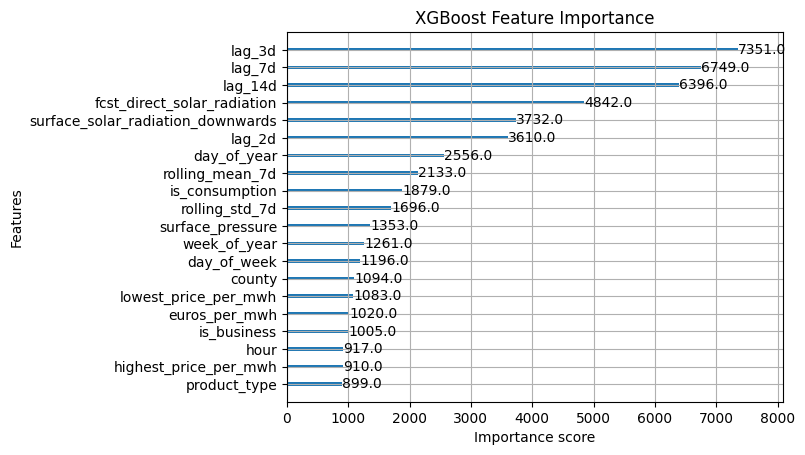

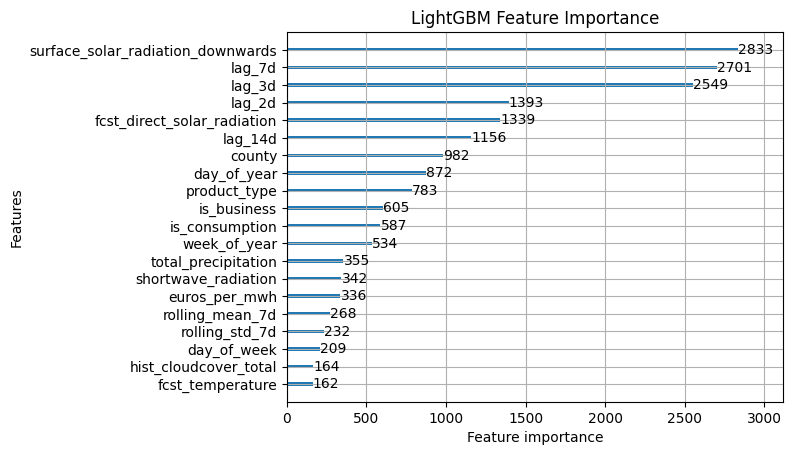

In [13]:
# XGBoost has a built-in plot function
xgb.plot_importance(xgb_reg, max_num_features = 20)
plt.title('XGBoost Feature Importance')
plt.show()

lgb.plot_importance(lgb_reg, max_num_features = 20)
plt.title('LightGBM Feature Importance')
plt.show()

# Phase 7 — Hyperparameter Tuning with Optuna

## Approach
We use **Bayesian optimisation** (Tree-structured Parzen Estimator) rather than grid or 
random search. Optuna learns from each trial to make progressively smarter guesses about 
where the best parameters are.

**TimeSeriesSplit CV (3 folds)** is used inside each trial — random k-fold would cause 
temporal leakage within the tuning process itself.

`n_estimators` is fixed at 1500 with early stopping, rather than tuned as a trial parameter. 
This lets the optimal number of trees be found automatically per fold.

## Search Space
| Parameter | Range | Scale |
|---|---|---|
| `learning_rate` | 0.01 – 0.1 | Log |
| `max_depth` | 3 – 10 | Integer |
| `subsample` | 0.5 – 1.0 | Uniform |
| `colsample_bytree` | 0.5 – 1.0 | Uniform |
| `min_child_weight` | 1 – 10 | Integer |

## Results (25 trials)
| Metric | Value |
|---|---|
| CV MAE (Optuna, 3-fold) | 46.14 |
| Val MAE (tuned model) | **58.06** |
| Improvement vs default XGBoost | −3.7% |
| Improvement vs persistence baseline | **−41.4%** |

**Note:** CV MAE (46.14) < Val MAE (57.40) — a normal generalisation gap. CV folds operate 
within the training period; the true val set is 5 months of genuinely unseen future data.
Always report the held-out val MAE as the real performance number.

In [16]:
# Opunta Tuning, XGBoost goes first
import optuna
from sklearn.model_selection import TimeSeriesSplit
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

df_optuna = df_merged.sort_values('datetime').reset_index(drop=True)

df_optuna_train = df_optuna[df_optuna['datetime']<split_date]
df_optuna_train = df_optuna_train.dropna(subset = ['target'])
X_optuna = df_optuna_train[features]
y_optuna = df_optuna_train['target']

tscv_reg = TimeSeriesSplit(n_splits=3)

def objective_xgb(trial):
    params = {
        'objective':             'reg:absoluteerror',
        'eval_metric':           'mae',
        'device':                'cuda',
        'n_estimators':          1500,
        'early_stopping_rounds': 50,
        'random_state':          42,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
    }
    
    fold_xgb_maes = []
    
    for tr_idx, val_idx in tscv_reg.split(X_optuna):
        X_tr_optuna, X_val_optuna = X_optuna.iloc[tr_idx], X_optuna.iloc[val_idx]
        y_tr_optuna, y_val_optuna = y_optuna.iloc[tr_idx], y_optuna.iloc[val_idx]

        xgb_optuna = xgb.XGBRegressor(**params)
        xgb_optuna.fit(
            X_tr_optuna, y_tr_optuna,
            eval_set = [(X_val_optuna, y_val_optuna)],
            verbose  = False,
        )
        preds_xgb_optuna = xgb_optuna.predict(cp.array(X_val_optuna))
        fold_xgb_maes.append(mean_absolute_error(y_val_optuna, preds_xgb_optuna))

    return np.mean(fold_xgb_maes)

study_xgb_reg = optuna.create_study(direction='minimize', 
                                    sampler=TPESampler(seed=42))

study_xgb_reg.optimize(objective_xgb, n_trials=25, show_progress_bar=True)

print(f"Best MAE:    {study_xgb_reg.best_value:.4f}")
print(f"Best params: {study_xgb_reg.best_params}")

  0%|          | 0/25 [00:00<?, ?it/s]

Best MAE:    46.1443
Best params: {'learning_rate': 0.02432502040522753, 'max_depth': 10, 'subsample': 0.9847685553939329, 'colsample_bytree': 0.5148027085118481, 'min_child_weight': 7}


In [17]:
best_xgb_params = study_xgb_reg.best_params

final_xgb_params = {
        'objective':             'reg:absoluteerror',
        'eval_metric':           'mae',
        'device':                'cuda', 
        'n_estimators':          3000,
        'early_stopping_rounds': 50,
        'random_state':          42,
        **best_xgb_params
}

final_xgb_reg = xgb.XGBRegressor(**final_xgb_params)
final_xgb_reg.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = False,
)

preds_xgb_best = final_xgb_reg.predict(X_val)
final_xgb_mae  = mean_absolute_error(y_val, preds_xgb_best)

print(f"Persistence Baseline MAE: {persistence_mae:.4f}")
print(f"XGBoost default MAE:      {xgb_mae:.4f}")
print(f"XGBoost tuned MAE:        {final_xgb_mae:.4f}")
print(f"Best params: {best_xgb_params}")

Persistence Baseline MAE: 99.0384
XGBoost default MAE:      60.2881
XGBoost tuned MAE:        58.0635
Best params: {'learning_rate': 0.02432502040522753, 'max_depth': 10, 'subsample': 0.9847685553939329, 'colsample_bytree': 0.5148027085118481, 'min_child_weight': 7}


# Phase 8 — SHAP Analysis

Feature importance measures how often a feature was used to split — it does not measure 
how much it moved the prediction. **SHAP (SHapley Additive exPlanations)** answers a 
deeper question: for each prediction, how much did each feature contribute?

Every prediction decomposes as:

**prediction = baseline + SHAP(lag_2d) + SHAP(lag_7d) + ... + SHAP(fcst_temperature) + ...**

## Global Summary Plot
Shows which features matter most across all validation predictions, and in which direction.

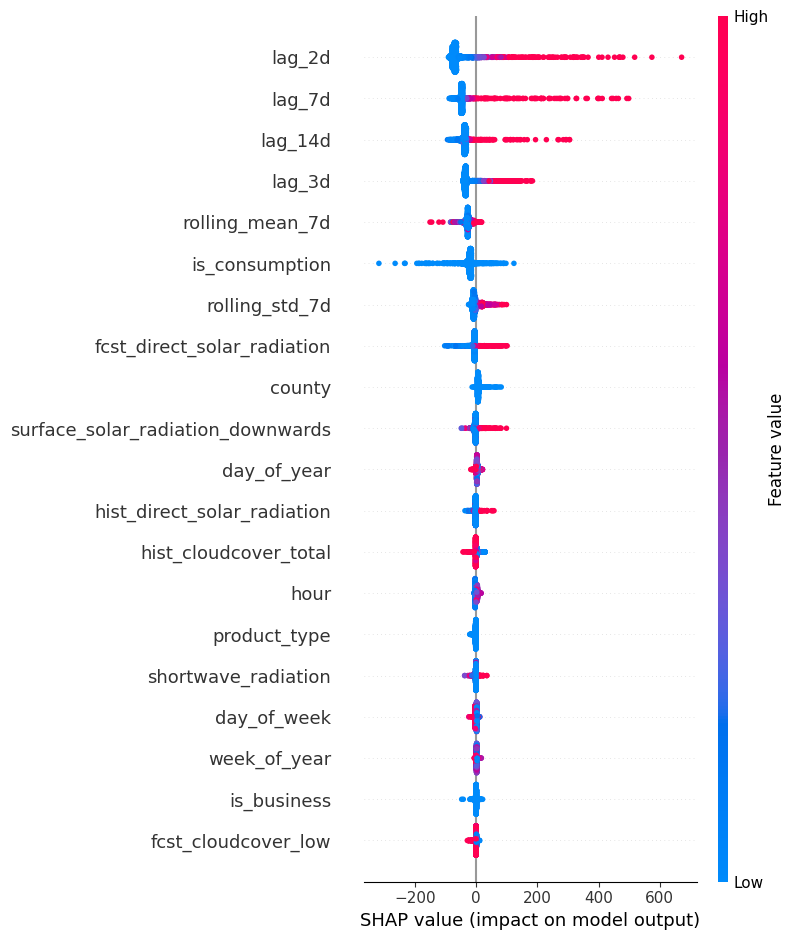

In [18]:
import shap

explainer = shap.TreeExplainer(final_xgb_reg)
X_val_sample = X_val.iloc[:2000]
shap_values = explainer.shap_values(X_val_sample)

# Global summary for top 20 features
shap.summary_plot(shap_values, X_val_sample, max_display = 20, show = True)

## Waterfall Plot
Shows why the model made one specific prediction — how each feature pushed the output 
up or down from the baseline.

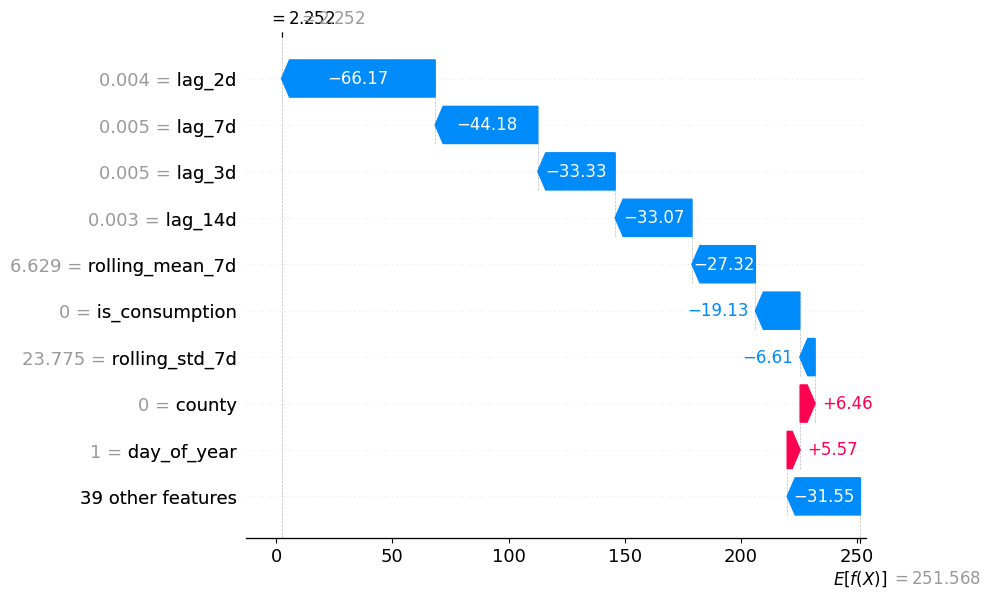

In [19]:
# individual SHAP explanation
shap.plots.waterfall(explainer(X_val_sample)[0])

## Key Findings
- **Lag features dominate** — `lag_2d`, `lag_7d`, `lag_14d` are the top 3 SHAP features.
  Past energy imbalance is the strongest predictor of future imbalance (autoregression works).
- **High lag values push prediction up** — physically sensible autocorrelation.
- **Solar radiation appears in LightGBM top features** — expected for a prosumer dataset 
  where solar panel generation directly drives energy imbalance.
- **Baseline: −31.55** — the mean prediction if no prosumer-specific information were used.

as